# Combo: Alien Exam

Agents evaluated on skinned (opaque) diagnosis tasks at multiple difficulty levels.

In [1]:
import sys
from pathlib import Path

# Ensure alienbio is importable
_root = Path(".").resolve().parent.parent / "src"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
_demos = Path(".").resolve().parent
if str(_demos) not in sys.path:
    sys.path.insert(0, str(_demos))

%matplotlib inline


In [2]:
from _shared import make_disease_system, oracle_agent, random_agent, zero_agent
from alienbio.bio import (
    AgentInterface, BioSystem, TestSuite,
    compare, generate_diagnosis_task, generate_name_map, run_suite, skin_task_description,
)
from alienbio.viz import difficulty_curve_plot, agent_comparison_chart

system, _, perturbations = make_disease_system(seed=42)
name_map = generate_name_map(system, seed=42)
agents = {"oracle": oracle_agent, "random": random_agent, "zero": zero_agent}


## Difficulty Curves (Skinned Tasks)

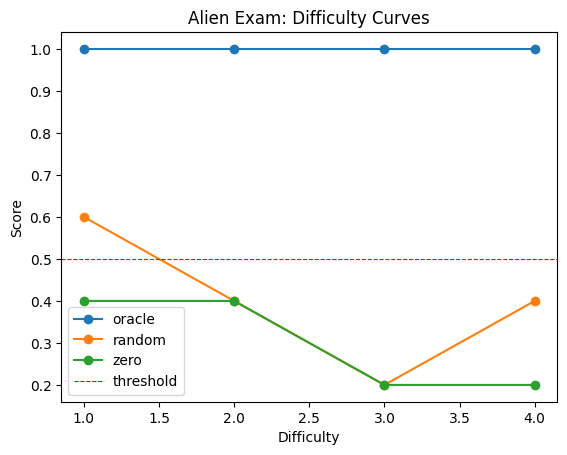

In [3]:
curves = {name: [] for name in agents}
for diff in [1, 2, 3, 4]:
    for agent_name, agent_fn in agents.items():
        suite = TestSuite(name=f"{agent_name}_d{diff}")
        for trial in range(5):
            task = generate_diagnosis_task(system, perturbations, difficulty=diff, seed=diff*100+trial)
            skin_task_description(task, name_map)
            interface = AgentInterface(BioSystem(system.chemistry, system.state.copy(), dt=0.1))
            suite.add(interface, task)
        results = run_suite(suite, agent_fn)
        curves[agent_name].append((diff, results.mean_score))

difficulty_curve_plot(curves, title="Alien Exam: Difficulty Curves");


## Leaderboard (Difficulty 3)

  oracle: mean=1.00
  random: mean=0.20
  zero: mean=0.10


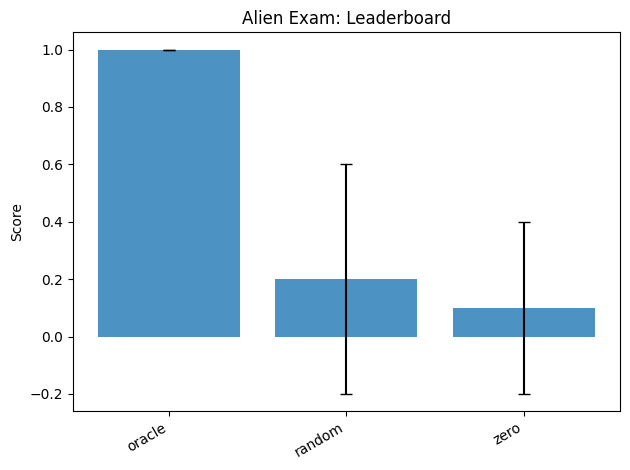

In [4]:
all_results = {}
for agent_name, agent_fn in agents.items():
    suite = TestSuite(name=agent_name)
    for trial in range(10):
        task = generate_diagnosis_task(system, perturbations, difficulty=3, seed=300+trial)
        interface = AgentInterface(BioSystem(system.chemistry, system.state.copy(), dt=0.1))
        suite.add(interface, task)
    all_results[agent_name] = run_suite(suite, agent_fn)

table = compare(all_results)
for a in table.ranking:
    print(f"  {a.agent_name}: mean={a.mean:.2f}")
agent_comparison_chart(table, title="Alien Exam: Leaderboard");
